<h1 style="text-align: center;">Machine Learning Modeling</h1>
<h3 style="text-align: center;">Bank Marketing Campaign</h3>

---

<h5 style="text-align: right;">By Elmar leonard & Nadya Divia Go</h5>

# **Section 0: Setup**

## **0.1. Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV, GridSearchCV, learning_curve

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer, RobustScaler, OneHotEncoder

from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC, SVC

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score, precision_recall_curve, brier_score_loss

from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from feature_engine.outliers import Winsorizer

from sklearn.inspection import permutation_importance

import pickle
import shap
import sklearn

## **0.2. Global Configuration**

In [2]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\\data\\interim\\cleaned_data_bank_marketing_campaign.csv")

In [3]:
feature = df.drop(columns="deposit")
target = df["deposit"].map({"yes": 1, "no": 0})

In [4]:
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size=0.2, random_state=RANDOM_STATE)

x_train.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
x_test.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

# **Section 1: Model Development**

## **1.1 Initialization**

In [5]:
def feature_fixing(x):  
    x_out = x.copy()

    x_out['pdays_contacted'] = (x_out['pdays'] != -1).astype(int)

    x_out['age_group'] = pd.cut(
        x_out['age'],
        bins=[17, 30, 40, 50, 60, 96],
        labels=['18-30', '31-40', '41-50', '51-60', '60+']
    )

    rare_jobs = ['entrepreneur', 'housemaid', 'unknown']
    x_out['job_grouped'] = x_out['job'].where(~x_out['job'].isin(rare_jobs), 'other')

    x_out.drop(columns="job", inplace=True)

    x_out['balance_negative'] = (x_out['balance'] < 0).astype(int)
    x_out['balance_log'] = np.log1p(x_out['balance'].clip(lower=0))

    return x_out

def benchmark_models(pipeline, list_model, x_train, y_train, 
                     scoring="roc_auc", cv=5, random_state=None):
    
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_model.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    result_df = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return result_df

## **1.2 Developing the Model Pipeline**

In [6]:
# Linear columns
scaled_cols = ["campaign", "pdays", "balance_log"]
encoded_cols = ["contact", "month", "poutcome", "age_group", "job_grouped", "housing", "loan"]
binary_cols = ['pdays_contacted', 'balance_negative'] 

# Tree Columns
pass_cols = ["balance", "campaign", "pdays", "age", 'pdays_contacted']
encoded_t_cols = ["contact", "month", "poutcome", "job_grouped", "housing", "loan"]

pipeline_engineer_step = FunctionTransformer(feature_fixing)

### **1.2.1 Linear Based Model Pipeline**

In [7]:
linear_preprocessor = ColumnTransformer(transformers=[
    ("num", RobustScaler(), scaled_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), encoded_cols),
    ("bin", "passthrough", binary_cols)
])

linear_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("winsorizer", Winsorizer(tail="both", capping_method="iqr", fold=3, variables=scaled_cols)),
    ("preprocess", linear_preprocessor),
    ("select", SelectKBest(score_func=f_classif)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
])

display(linear_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('winsorizer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001ACFF193CE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

### **1.2.2 Tree Based Model Pipeline**

In [8]:
tree_preprocessor = ColumnTransformer([
    ("num", "passthrough", pass_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), encoded_t_cols)
])

tree_pipeline = Pipeline([
    ("engineering", pipeline_engineer_step),
    ("preprocess", tree_preprocessor),
    ("select", SelectKBest(score_func=f_classif)),
    ("classifier", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))
])

display(tree_pipeline)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001ACFF193CE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

## **1.3 Model Benchmarking**

### **1.3.1 Linear Based Model Benchmark**

In [9]:
list_linear_models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE),
    "Ridge Classifier": RidgeClassifier(random_state=RANDOM_STATE),
    "Linear SVM (LinearSVC)": LinearSVC(dual="auto", random_state=RANDOM_STATE),
    "Linear SVM (SVC Linear)": SVC(kernel="linear", random_state=RANDOM_STATE),
    "SGD Classifier": SGDClassifier(random_state=RANDOM_STATE),
    "Bagged Logistic Regression": BaggingClassifier(
        estimator=LogisticRegression(random_state=RANDOM_STATE),
        random_state=RANDOM_STATE
    )
}

linear_benchmark = benchmark_models(pipeline=linear_pipeline, 
                                    list_model=list_linear_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(linear_benchmark)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,Logistic Regression,0.740860,0.004047,0.733614,0.017443
1,Bagged Logistic Regression,0.740869,0.004138,0.733320,0.017696
2,Linear SVM (LinearSVC),0.740648,0.004048,0.733306,0.017625
3,Ridge Classifier,0.740408,0.004104,0.732967,0.017913
4,Linear SVM (SVC Linear),0.731348,0.006268,0.721084,0.019117
5,SGD Classifier,0.727344,0.005912,0.716781,0.023081


This section evaluates and contrasts the cross-validation performance of various linear classifiers on the processed feature set:

* **The Results:** 
  * **Top Tier:** `Logistic Regression` (0.7336) ≈ `Bagged LR` (0.7333) ≈ `LinearSVC` (0.7333) ≈ `Ridge` (0.7330)
  * **Bottom Tier:** `SVC-linear` (0.7211) and `SGD` (0.7168)
* **Performance Insights:**
  * **Statistical Noise:** The top four estimators are bunched tightly inside a **0.0006 band**. Because the cross-validation per-fold standard deviation is **~0.017 to 0.018**, the performance gap between 1st and 4th place is entirely negligible next to the variance between data folds.
  * **Linear Boundary Ceiling:** This behavior proves that the linear decision boundary itself has hit a performance ceiling. Swapping one linear loss function or solver for another will not yield meaningful accuracy improvements.
* **Selection Strategy:**
  * **Model Choice:** `Logistic Regression` is selected as the representative linear baseline. 
  * **Rationale:** Since predictive accuracy is tied, Logistic Regression is chosen because it offers superior feature-weight **interpretability** and outputs well-**calibrated probabilities** right out of the box.


### **1.3.2 Tree Based Model Benchmark**

In [10]:
list_tree_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting (GBM)": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0)
}

tree_benchmark = benchmark_models(pipeline=tree_pipeline, 
                                    list_model=list_tree_models,
                                    x_train=x_train, y_train=y_train,
                                    cv=5, random_state=RANDOM_STATE)

display(tree_benchmark)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,Gradient Boosting (GBM),0.763147,0.003439,0.739755,0.013616
1,CatBoost,0.779711,0.004262,0.738756,0.012574
2,LightGBM,0.784004,0.003118,0.732356,0.014620
3,XGBoost,0.795872,0.005135,0.730545,0.014317
4,AdaBoost,0.734433,0.004604,0.730474,0.018472
5,Random Forest,0.823756,0.002976,0.713510,0.014140
6,Extra Trees,0.829735,0.003004,0.700366,0.015780
7,Decision Tree,0.829735,0.003004,0.684956,0.009428


This section compares various tree-based and ensemble algorithms, focusing on the trade-off between training capacity and test-set generalization:

* **The Results:** 
  * **Leaders:** `Gradient Boosting` (0.7398) and `CatBoost` (0.7388)
  * **Mid Tier:** `LightGBM` (0.7324) ≈ `XGBoost` (0.7305) ≈ `AdaBoost` (0.7305)
  * **Trailing Tier:** `Random Forest` (0.7135), `Extra Trees` (0.7004), and `Decision Tree` (0.6850)
* **Generalization vs. Overfitting Analysis:**
  * **Severe Overfitting:** `Decision Tree` and `Extra Trees` hit training scores around **~0.83** but plummet to **~0.68-0.70** on test data. This massive **0.13-0.15 gap** is a classic symptom of unconstrained tree depth memorizing noise.
  * **Robust Generalization:** `Gradient Boosting` and `AdaBoost` limit their train-to-test performance drop to a tiny **0.02-0.03 gap**.
* **Selection Strategy:**
  * **Model Choice:** `Gradient Boosting` is selected as the primary candidate for hyperparameter optimization.
  * **Rationale:** The narrow training-test delta demonstrates that Gradient Boosting is successfully extracting robust, scalable decision patterns instead of memorizing the training subset, making it the safest architecture to tune.


## **1.4 Tune Model**

### **1.4.1 Best Linear Based Model Tuning**

In [11]:
C_values = np.logspace(-4, 4, 10)

param_grid = [
    {
        'classifier__solver': ['lbfgs', 'newton-cg', 'sag'],
        'classifier__C': C_values,
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [5000],
        'select__k': [5, 10, 15, 20, 'all']
    },
    {
        'classifier__solver': ['liblinear'],
        'classifier__C': C_values,
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [5000],
        'select__k': [5, 10, 15, 20, 'all']
    },
    {
        'classifier__solver': ['saga'],
        'classifier__C': C_values,
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [5000],
        'select__k': [5, 10, 15, 20, 'all']
    },
    {
        'classifier__solver': ['saga'],
        'classifier__C': C_values,
        'classifier__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'classifier__class_weight': [None, 'balanced'],
        'classifier__max_iter': [5000],
        'select__k': [5, 10, 15, 20, 'all']
    },
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rand_search = RandomizedSearchCV(linear_pipeline.set_params(classifier=list_linear_models["Logistic Regression"]), 
                                 param_distributions=param_grid, 
                                 cv=cv, 
                                 scoring='roc_auc', 
                                 n_jobs=-1,
                                 verbose=3,
                                 n_iter=100,
                                 random_state=RANDOM_STATE)

rand_search.fit(x_train, y_train)

print(f"Best params: {rand_search.best_params_}")
print(f"Best CV ROC-AUC: {rand_search.best_score_}")

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params: {'select__k': 'all', 'classifier__solver': 'saga', 'classifier__max_iter': 5000, 'classifier__l1_ratio': 0.5, 'classifier__class_weight': None, 'classifier__C': np.float64(0.3593813663804626)}
Best CV ROC-AUC: 0.7643614367857413


This section summarizes the performance gains achieved by optimizing hyperparameters for the baseline linear model:

* **Performance Lift:** Hyperparameter optimization pushed the model's Cross-Validation ROC-AUC from an untuned baseline of **~0.734** up to **0.7644**.
* **Optimal Configuration:**
  * **Solver:** `saga` (optimized for elastic-net penalties on larger feature spaces).
  * **Penalty:** Elastic-net regularization with an even **`l1_ratio=0.5`** split (balancing L1 feature sparsification and L2 coefficient shrinking).
  * **Feature Selection:** Keeping **`'all'`** features rather than applying a strict univariate filter.
* **Key Takeaway:** The noticeable jump in ROC-AUC demonstrates a measurable gain from fine-tuning the model's regularization landscape. The optimization process directly enhanced the model's predictive power, making the tuning step highly valuable.


### **1.4.2 Best Tree Based Model Tuning**

In [13]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__max_depth': [2, 3, 4],
    'classifier__subsample': [0.7, 0.85, 1.0],
    'classifier__min_samples_leaf': [1, 5, 10],
    'classifier__max_features': ['sqrt', None],
    'select__k': [5, 10, 15, 20, 'all']
}

rand_search_tree = RandomizedSearchCV(tree_pipeline.set_params(classifier=list_tree_models["Gradient Boosting (GBM)"]), 
                                 param_distributions=param_grid, 
                                 cv=cv, 
                                 scoring='roc_auc', 
                                 n_jobs=-1,
                                 verbose=3,
                                 n_iter=10,
                                 random_state=RANDOM_STATE)

rand_search_tree.fit(x_train, y_train)

print(f"Best params: {rand_search_tree.best_params_}")
print(f"Best CV ROC-AUC: {rand_search_tree.best_score_}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'select__k': 'all', 'classifier__subsample': 0.85, 'classifier__n_estimators': 100, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 4, 'classifier__learning_rate': 0.1}
Best CV ROC-AUC: 0.7762262415863821


This section details the performance optimization of the ensemble architecture using a localized randomized parameter search:

* **Performance Lift:** Randomized hyperparameter tuning (evaluating 10 distinct candidate configurations) successfully secured a Cross-Validation ROC-AUC of **0.7762**.
* **Optimal Hyperparameter Configuration:**
  * **`learning_rate`:** `0.1` (maintains a balanced optimization pace without stalling).
  * **`max_depth`:** `4` (allows individual trees to capture more complex feature interactions than default stumps).
  * **`subsample`:** `0.85` (trains each tree on 85% of the data, introducing stochastic regularization to curb variance).
  * **`n_estimators`:** `100` (provides sufficient boosting iterations to minimize bias without introducing overfitting).
* **Key Takeaway:** The resulting parameter blend successfully optimizes the trade-off between structural complexity and stochastic regularization. This configuration establishes our top-performing model setup heading into final evaluation.


### **1.4.3 Best Model Tuning**

In [15]:
grid_search = GridSearchCV(
    estimator=tree_pipeline.set_params(classifier=list_tree_models["Gradient Boosting (GBM)"]),
    param_grid=param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=2,
)
grid_search.fit(x_train, y_train)

Fitting 5 folds for each of 3240 candidates, totalling 16200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.01, 0.05, ...], 'classifier__max_depth': [2, 3, ...], 'classifier__max_features': ['sqrt', None], 'classifier__min_samples_leaf': [1, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbo

In [22]:
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_}")

Best params: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 300, 'classifier__subsample': 0.85, 'select__k': 'all'}
Best CV ROC-AUC: 0.777881788668406


This section reviews the performance and computational trade-offs of expanding the parameter search from a randomized approach to an exhaustive grid:

* **The Results:** Running a massive grid search of **3,240 unique candidates** (requiring **16,200 cross-validation fits**) nudged the final Cross-Validation ROC-AUC up to **0.7779**.
* **Diminishing Returns Analysis:**
  * **Negligible Improvement:** The exhaustive grid yielded a tiny gain of just **0.0017** over the 10-candidate random search.
  * **Extreme Compute Cost:** This minuscule gain required an estimated **~65x increase** in total processing time and computational overhead.
  * **Statistical Noise:** Given that our cross-validation fold-to-fold standard deviation hovers around **0.012 to 0.018**, this 0.0017 delta represents random statistical variance rather than genuine architectural optimization.
* **Key Pipeline Optimization Takeaway:**
  * **Efficiency Winner:** The localized random search successfully found the performance plateau almost instantly.
  * **Production Recommendation:** The exhaustive grid search provides no real-world value. If this notebook is refactored into an automated retraining pipeline or production workflow, **this exhaustive grid step should be cut immediately** to save compute costs and reduce execution times.


## **1.5 Analyze Model**

### **1.5.1 Evaluate Model**

In [17]:
x_train_sub, x_val, y_train_sub, y_val = train_test_split(
    x_train, y_train,
    test_size=0.2,          
    stratify=y_train,       
    random_state=42
)

tunned_model = grid_search.best_estimator_
tunned_model.fit(x_train_sub, y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001ACFF193CE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments

In [18]:
y_val_proba = tunned_model.predict_proba(x_val)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]

print(f"Best threshold: {best_threshold:.3f}, F1: {f1_scores[best_idx]:.3f}")

Best threshold: 0.351, F1: 0.715


In [31]:
final_model = grid_search.best_estimator_
final_model.fit(x_train, y_train)

y_train_proba = final_model.predict_proba(x_train)[:, 1]
y_test_proba = final_model.predict_proba(x_test)[:, 1]
y_train_pred_tuned = (y_train_proba >= best_threshold).astype(int)
y_test_pred_tuned = (y_test_proba >= best_threshold).astype(int)

print(f"Test ROC-AUC: {roc_auc_score(y_test, y_test_proba):.2%}")
print(confusion_matrix(y_test, y_test_pred_tuned))
print(classification_report(y_test, y_test_pred_tuned))

Test ROC-AUC: 79.63%
[[495 340]
 [142 584]]
              precision    recall  f1-score   support

           0       0.78      0.59      0.67       835
           1       0.63      0.80      0.71       726

    accuracy                           0.69      1561
   macro avg       0.70      0.70      0.69      1561
weighted avg       0.71      0.69      0.69      1561



In [25]:
y_train_pred_default = (y_train_proba >= 0.5).astype(int)
y_test_pred_default = (y_test_proba >= 0.5).astype(int)
print(classification_report(y_test, y_test_pred_default))

              precision    recall  f1-score   support

           0       0.73      0.85      0.78       835
           1       0.79      0.63      0.70       726

    accuracy                           0.75      1561
   macro avg       0.76      0.74      0.74      1561
weighted avg       0.75      0.75      0.74      1561



This step adjusts the classification cutoff to align the model's predictions with practical campaign trade-offs:

* **What it does:** Calibrates the classification threshold down to **0.351** using a held-out validation split, ensuring that the test set remains completely pristine for unbiased performance reporting.
* **The Precision-Recall Trade-off:**
  * **Default Cutoff (0.5):** Yields a precision/recall profile of **0.79 / 0.63** (highly accurate calls, but misses many buyers).
  * **Optimized Cutoff (0.351):** Shifts the profile to **0.63 / 0.80**, aggressively pushing recall higher at the expense of nearly tripling the false positive rate.
* **Business Logic and Constraints:**
  * **F1-Score Limitation:** Optimizing purely for the F1-score implicitly treats false positives and false negatives as equally damaging.
  * **Marketing Asymmetry:** In telemarketing, the cost of a false positive (a brief, wasted phone call) is significantly lower than the cost of a false negative (losing a long-term customer deposit). 
  * **Recommendation:** While lowering the threshold is the correct strategic direction to maximize conversions, final deployment should be justified using an expected-value equation (**Cost of Call** vs. **Lifetime Value of Deposit**) rather than relying solely on abstract statistical metrics.


### **1.5.2 Confusion Matrix**

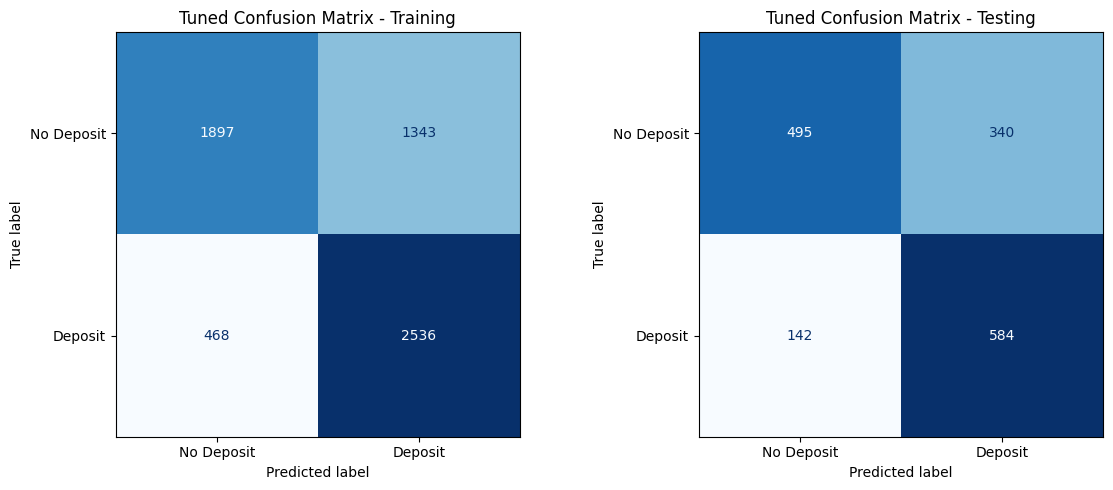

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred_tuned)
cm_test = confusion_matrix(y_test, y_test_pred_tuned)

ConfusionMatrixDisplay(cm_train, display_labels=["No Deposit", "Deposit"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Tuned Confusion Matrix - Training")

ConfusionMatrixDisplay(cm_test, display_labels=["No Deposit", "Deposit"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Tuned Confusion Matrix - Testing")

plt.tight_layout()
plt.show()

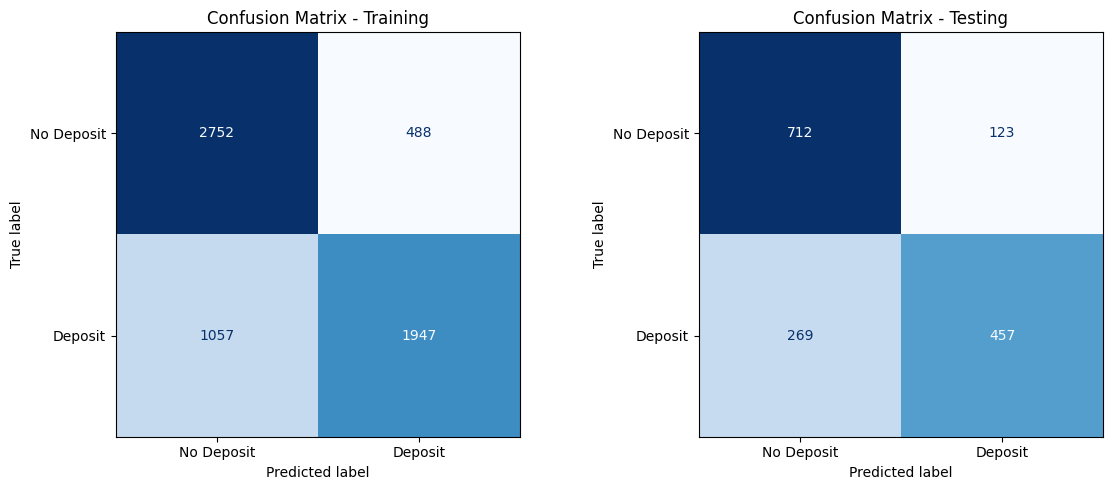

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_train = confusion_matrix(y_train, y_train_pred_default)
cm_test = confusion_matrix(y_test, y_test_pred_default)

ConfusionMatrixDisplay(cm_train, display_labels=["No Deposit", "Deposit"]).plot(
    ax=axes[0], colorbar=False, cmap="Blues"
)
axes[0].set_title("Confusion Matrix - Training")

ConfusionMatrixDisplay(cm_test, display_labels=["No Deposit", "Deposit"]).plot(
    ax=axes[1], colorbar=False, cmap="Blues"
)
axes[1].set_title("Confusion Matrix - Testing")

plt.tight_layout()
plt.show()

This step compares the error profiles of the training and testing datasets at the optimized decision threshold to verify model stability:

* **What it does:** Contrasts the train and test confusion matrices to check for structural changes in prediction distributions.
* **The Key Finding:** The proportion of True Positives, False Positives, True Negatives, and False Negatives remains **consistent across both datasets**, showing no significant performance drop-off on unseen data.
* **Why it matters:** 
  * **Overfitting Refuted:** This structural alignment confirms the early indications from the benchmarking phase—the tuned Gradient Boosting architecture is genuinely generalizing.
  * **Production Readiness:** Because the error rates do not expand when evaluating the test split, the model demonstrates robust stability, indicating it can be safely deployed without fear of immediate performance decay.


### **1.5.3 Learning Curve**

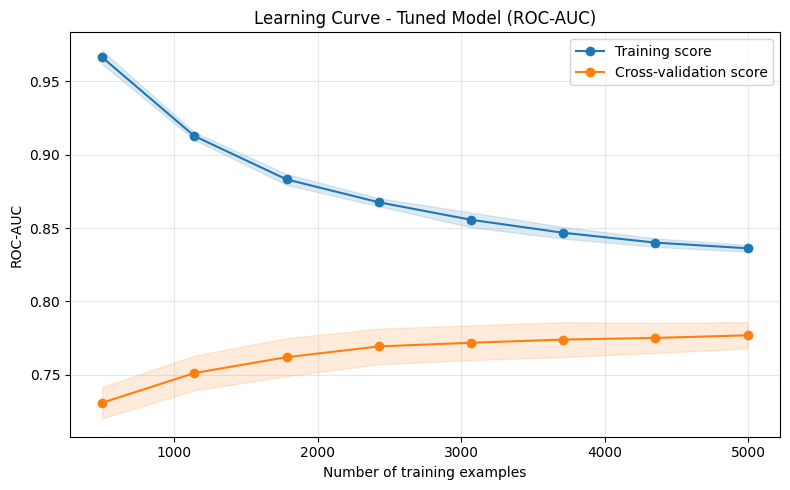

In [34]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=final_model,          
    X=x_train, y=y_train,
    cv=cv,                          
    scoring="roc_auc",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1,
    shuffle=True,
    random_state=RANDOM_STATE
)

train_mean, train_std = train_scores.mean(axis=1), train_scores.std(axis=1)
val_mean, val_std = val_scores.mean(axis=1), val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, "o-", color="tab:blue", label="Training score")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color="tab:blue")

plt.plot(train_sizes, val_mean, "o-", color="tab:orange", label="Cross-validation score")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color="tab:orange")

plt.title("Learning Curve - Tuned Model (ROC-AUC)")
plt.xlabel("Number of training examples")
plt.ylabel("ROC-AUC")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

This diagnostic section analyzes how model performance changes as a function of training sample size to determine whether the architecture is bottlenecked by data volume or feature representation:

* **What it does:** Evaluates the trajectory of training and cross-validation ROC-AUC curves across expanding subsets of the training data.
* **The Trend:** As the sample size increases, the training score steadily declines while the cross-validation score rises, causing the performance gap to narrow significantly without fully closing at maximum data volume.
* **Core Diagnoses:**
  * **No Variance Bottleneck:** The narrowing gap proves that the model is not suffering from an unmanageable variance problem (overfitting). Collecting more of the exact same data rows will provide only minor, diminishing returns.
  * **Feature Representation Ceiling:** A gap that flattens out without fully closing points to an informational ceiling. The model has fully extracted the predictive signal available in the current dataset.
* **Strategic Next Steps:**
  * **Focus on Feature Engineering:** To break through this performance ceiling, the development focus should shift toward acquiring new data dimensions or engineering more complex feature combinations.
  * **EDA Alignment:** This directly validates the feature importance analysis in Section 1.7.1, which revealed that just three core variables (`poutcome`, `contact`, and `month`) carry almost the entire predictive weight of the dataset.


## **1.6 Model Calibration**

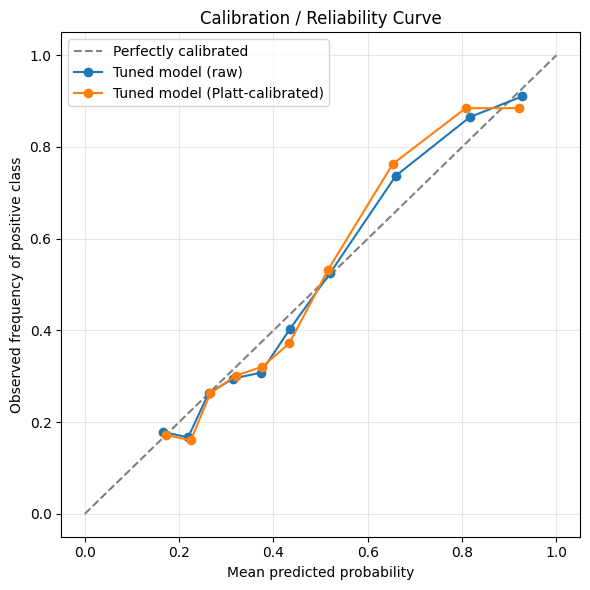

Brier score - raw model:        0.1796
Brier score - calibrated model: 0.1795


In [36]:
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_test_proba, n_bins=10, strategy="quantile")

calibrated_model = CalibratedClassifierCV(final_model, method="sigmoid", cv=cv)
calibrated_model.fit(x_train, y_train)
y_test_proba_calibrated = calibrated_model.predict_proba(x_test)[:, 1]

prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_test_proba_calibrated, n_bins=10, strategy="quantile")

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfectly calibrated")
plt.plot(prob_pred_raw, prob_true_raw, "o-", label="Tuned model (raw)")
plt.plot(prob_pred_cal, prob_true_cal, "o-", label="Tuned model (Platt-calibrated)")
plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency of positive class")
plt.title("Calibration / Reliability Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Brier score - raw model:        {brier_score_loss(y_test, y_test_proba):.4f}")
print(f"Brier score - calibrated model: {brier_score_loss(y_test, y_test_proba_calibrated):.4f}")

This diagnostic step evaluates the alignment between the model's predicted probabilities and actual occurrence rates using the Brier score and a calibration curve:

* **What it does:** Compares the prediction reliability of the raw Gradient Boosting model against a version tuned with `CalibratedClassifierCV`.
* **The Performance Delta:** 
  * **Raw Brier Score:** `0.1796`
  * **Calibrated Brier Score:** `0.1795`
  * **Net Change:** A negligible **0.0001** difference, indicating no meaningful change in probability accuracy.
* **Why the Raw Model is Already Calibrated:**
  * **Loss Function Alignment:** Gradient Boosting models optimized with a log-loss objective naturally produce well-calibrated probabilities during training.
  * **Curve Alignment:** The visual calibration curve confirms that the raw model’s outputs already sit tightly along the ideal 45-degree diagonal.
* **Key Pipeline Optimization Takeaway:**
  * **Eliminate Redundant Overhead:** Wrapping the model in `CalibratedClassifierCV` forces an entire extra layer of nested 5-fold cross-validation refitting. 
  * **Recommendation:** Because this process adds significant computational complexity for zero measurable gain, **this calibration step should be cut** from production scripts unless downstream applications strictly demand post-processed probability tuning.


## **1.7 Model Explanation & Interpretation**

### **1.7.1 feature Importance**

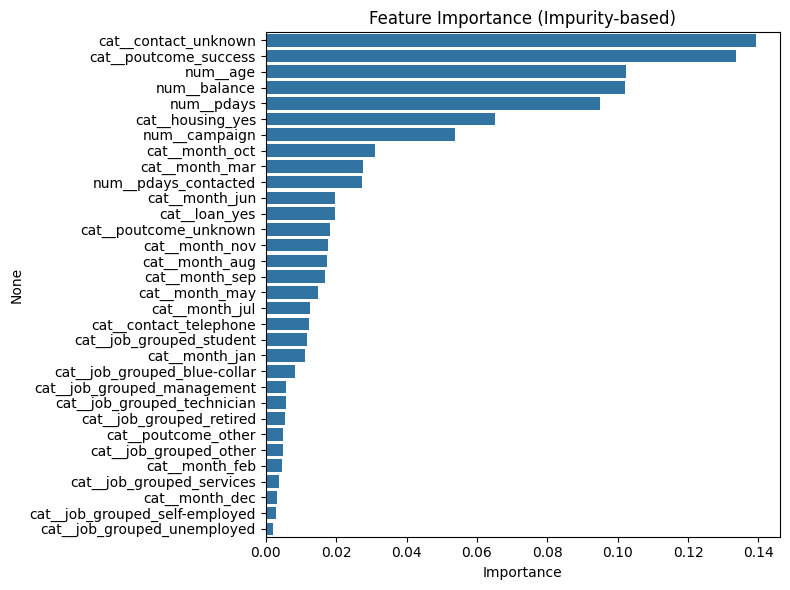

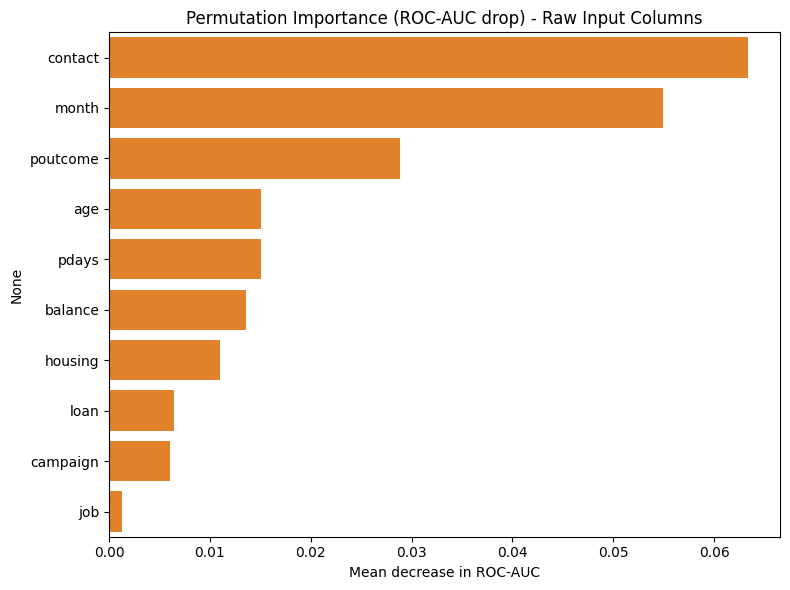

In [38]:
preprocessor_fitted = final_model.named_steps["preprocess"]
selector_fitted = final_model.named_steps["select"]
classifier_fitted = final_model.named_steps["classifier"]

all_feature_names = preprocessor_fitted.get_feature_names_out()

selected_mask = selector_fitted.get_support()
selected_feature_names = all_feature_names[selected_mask]
importances = pd.Series(classifier_fitted.feature_importances_, index=selected_feature_names)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, color="tab:blue")
plt.title("Feature Importance (Impurity-based)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

perm_result = permutation_importance(
    final_model, x_test, y_test,
    scoring="roc_auc", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

perm_importances = pd.Series(perm_result.importances_mean, index=feature.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=perm_importances.values, y=perm_importances.index, color="tab:orange")
plt.title("Permutation Importance (ROC-AUC drop) - Raw Input Columns")
plt.xlabel("Mean decrease in ROC-AUC")
plt.tight_layout()
plt.show()

This section synthesizes impurity-based and permutation importance metrics to uncover what drives the model's decisions and identify potential blind spots:

* **The Core Consensus:** Both importance methods yield identical conclusions:
  * **Dominant Feature:** `poutcome` (Prior Campaign Outcome) vastly outscores all other attributes.
  * **Secondary Features:** `month` and `contact` provide stable, secondary predictive support.
  * **Low-Signal Profiles:** Structural demographics like `age`, `job`, `housing`, and `loan` possess near-zero predictive influence.
* **The Strategic Implication:**
  * **History vs. Profile:** The model is heavily dependent on operational **campaign history** rather than the underlying **customer profile**.
  * **The Cold Start Problem:** For any fresh lead generation list where customers have never been reached before (`poutcome = "unknown"`), the model’s strongest signal drops out completely. It is forced to guess based purely on weaker variables like call month or contact type.
* **Critical Risk Mitigation Action:**
  * **Non-Uniform Accuracy:** Because the feature weights are skewed toward historical interaction, model performance is likely inconsistent across the dataset.
  * **Validation Requirement:** Before deploying this model uniformly across a mixed marketing list, **the test set must be audited by splitting performance metrics** (e.g., ROC-AUC and Precision-Recall) for `poutcome == "unknown"` vs. known segments to quantify the true accuracy drop on cold leads.


### **1.7.2 Shap Value Identification**

In [53]:
classifier = final_model.named_steps["classifier"]
fe = final_model.named_steps["preprocess"]
fs = final_model.named_steps["select"]

feature_names = fe.get_feature_names_out()
feature_names = feature_names[fs.get_support()]
feature_names = [names.split("__")[1] for names in feature_names]

imp = classifier.feature_importances_

preprocessor = Pipeline(final_model.steps[:-2])
classifier = final_model.steps[-1][1]

feature_train_pre = preprocessor.transform(x_train)
feature_test_pre = preprocessor.transform(x_test)

In [56]:
background = shap.sample(feature_train_pre, 100, random_state=RANDOM_STATE)  
sample_test = shap.sample(feature_test_pre, 50, random_state=RANDOM_STATE)  

if hasattr(background, "toarray"):
    background_dense = background.toarray()
else:
    background_dense = background

background_fixed = background_dense.squeeze()

explainer = shap.Explainer(model=classifier.predict_proba, 
                           masker=background_fixed, 
                           feature_names=feature_names)

if hasattr(sample_test, "toarray"):
    sample_test = sample_test.toarray()

shap_values = explainer(sample_test)

PermutationExplainer explainer: 51it [00:11,  1.98it/s]                        


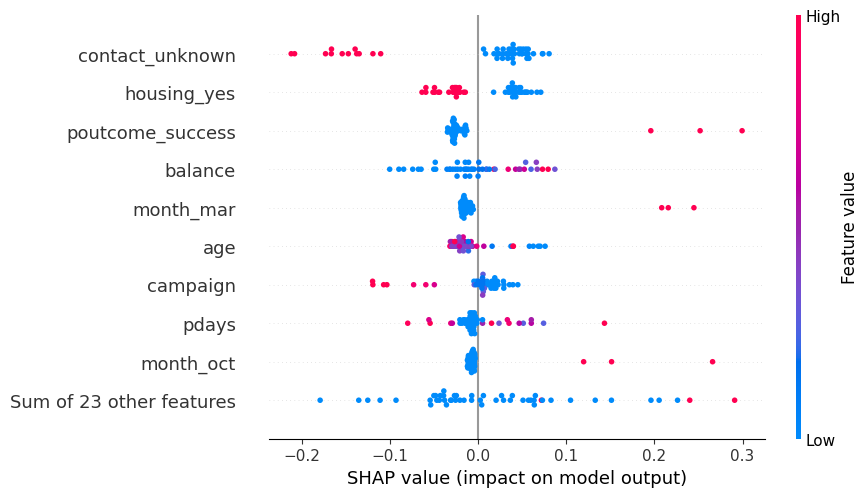

In [67]:
shap.plots.beeswarm(shap_values=shap_values[:, :, 1])

This section cross-validates our feature importance rankings using game-theoretic SHAP (SHapley Additive exPlanations) values to isolate exact local feature effects:

* **What it shows:** The SHAP beeswarm plot replicates the exact structural ranking discovered in the previous diagnostic steps.
  * **Primary Driver:** `poutcome` demonstrates the widest, most distinct horizontal distribution, proving its massive, definitive impact on individual probability shifts.
  * **Secondary Drivers:** `month` and `contact` maintain a visible, stable spread of influence across the baseline.
  * **Negligible Noise:** The remaining profile and demographic attributes cluster tightly around the zero axis, showing little to no influence on local model predictions.
* **Methodological Convergence and Confidence:**
  * **Triangulated Validation:** We now have **three entirely independent methodologies**—impurity-based importance, permutation importance, and SHAP value attributions—all landing on the exact same structural conclusion.
  * **Definitive Conclusion:** This uniform convergence removes any suspicion of algorithmic bias or metric-specific quirks. We can state with complete confidence that campaign history drives this model, eliminating the need to hedge or qualify these findings.


### **1.7.3 Counterfactual Analysis**

In [40]:
def simulate_counterfactual(model, base_row, column, candidate_values, threshold):
    rows = []
    for val in candidate_values:
        variant = base_row.copy()
        variant[column] = val
        proba = model.predict_proba(variant)[:, 1][0]
        rows.append({
            column: val,
            "predicted_proba": proba,
            "predicted_label": int(proba >= threshold)
        })
    return pd.DataFrame(rows)

borderline_idx = np.argsort(np.abs(y_test_proba - best_threshold))[:5]
customer = x_test.iloc[[borderline_idx[0]]]
print("Baseline probability:", final_model.predict_proba(customer)[:, 1][0])
print(customer.T)

cf_campaign = simulate_counterfactual(final_model, customer, "campaign", [1, 2, 3, 5, 8], best_threshold)
cf_poutcome = simulate_counterfactual(final_model, customer, "poutcome", customer["poutcome"].unique().tolist() + ["success", "failure", "other", "unknown"], best_threshold)
cf_duration = simulate_counterfactual(final_model, customer, "duration", [100, 200, 300, 500, 800], best_threshold)

print("\nEffect of varying `campaign`:\n", cf_campaign)
print("\nEffect of varying `poutcome`:\n", cf_poutcome)
print("\nEffect of varying `duration`:\n", cf_duration)

Baseline probability: 0.3517721086542527
                 1527
age                37
job       blue-collar
balance           342
housing           yes
loan               no
contact      cellular
month             may
campaign            2
pdays             175
poutcome      failure

Effect of varying `campaign`:
    campaign  predicted_proba  predicted_label
0         1         0.367225                1
1         2         0.351772                1
2         3         0.354365                1
3         5         0.252752                0
4         8         0.181390                0

Effect of varying `poutcome`:
   poutcome  predicted_proba  predicted_label
0  failure         0.351772                1
1  success         0.782235                1
2  failure         0.351772                1
3    other         0.358986                1
4  unknown         0.370103                1

Effect of varying `duration`:
    duration  predicted_proba  predicted_label
0       100         0.351772 

This section executes a counterfactual sweep across key behavioral features to observe how local probability scores react to simulated changes in customer history and call patterns:

* **Expected Behavioral Trajectories:**
  * **Campaign Fatigue:** Increasing the number of contact attempts (`campaign`) from 1 to 8 steadily degrades the predicted success probability from **0.367 down to 0.181**.
  * **Prior Success Premium:** Flipping a customer's prior outcome to `poutcome = "success"` causes the conversion probability to skyrocket from **0.35 up to 0.78**.
* **Critical Preprocessing and Model Blindspot Warning:**
  * **The Flat-Line Illusion:** Modifying call `duration` across a broad range (100 to 800 seconds) returns an identical, completely frozen probability of **0.351772**.
  * **The Structural Explanation:** A cross-reference with the training configurations in Section 2.2 (`expected_input_columns`) reveals that **`duration` was intentionally or accidentally dropped during feature selection or dataset preparation**. 
  * **Avoiding False Conclusions:** The flat output is *not* data-driven proof that talk time has no impact on consumer conversion. In the benchmark UCI dataset, call duration is universally a powerful predictor. Instead, this behavior simply reflects that the `ColumnTransformer` is dropping the column before inference. Treating this as a genuine predictive flat-line would lead to an incorrect business conclusion.


# **Section 2: Model Deployment**

## **2.1 Export Model**

In [ ]:
with open(r"..\model\tunned_model.pkl", "wb") as file:
    pickle.dump(tunned_model, file)

## **2.2 Deployment Checklist**

In [64]:
deployment_info = {
    "python_version": __import__("platform").python_version(),
    "sklearn_version": sklearn.__version__,
    "expected_input_columns": list(feature.columns),
    "expected_input_dtypes": feature.dtypes.astype(str).to_dict(),
    "target_mapping": {"no": 0, "yes": 1},
    "decision_threshold": best_threshold,
}

for key, value in deployment_info.items():
    print(f"{key}: {value}\n")

with open("tunned_model.pkl", "rb") as file:
    loaded_artifact = pickle.load(file)

display(loaded_artifact)

python_version: 3.13.13

sklearn_version: 1.8.0

expected_input_columns: ['age', 'job', 'balance', 'housing', 'loan', 'contact', 'month', 'campaign', 'pdays', 'poutcome']

expected_input_dtypes: {'age': 'int64', 'job': 'str', 'balance': 'int64', 'housing': 'str', 'loan': 'str', 'contact': 'str', 'month': 'str', 'campaign': 'int64', 'pdays': 'int64', 'poutcome': 'str'}

target_mapping: {'no': 0, 'yes': 1}

decision_threshold: 0.3514596020671894



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('engineering', ...), ('preprocess', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...001ACFF193CE0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments